In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import glob
import time
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

def build_contrastive_encoder(input_shape=(128, 128, 1)):
    """The backbone encoder: Extracts track morphology."""
    inputs = keras.Input(shape=input_shape)
    
    # Core Conv Blocks (kept identical to your architecture)
    x = layers.Conv2D(32, 3, strides=1, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Conv2D(64, 3, strides=1, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Conv2D(128, 3, strides=1, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    
    # Output of encoder is a 128-dimensional feature vector
    outputs = layers.GlobalAveragePooling2D()(x)
    
    return keras.Model(inputs, outputs, name="encoder_backbone")

def add_projection_head(encoder_model, embedding_dim=64):
    """The projection head used ONLY during Phase 1 (Contrastive Pre-training)."""
    inputs = encoder_model.input
    features = encoder_model.output
    
    # MLP projection head (No Dropout!)
    x = layers.Dense(128, activation="relu")(features)
    # Linear activation at the end for cosine similarity calculation
    projection = layers.Dense(embedding_dim, activation=None)(x) 
    
    return keras.Model(inputs, projection, name="contrastive_pretrain_model")

def add_classification_head(encoder_model):
    """The classification head used during Phase 2 (Fine-tuning & Inference)."""
    # Freeze the encoder weights so the physical feature extraction is preserved
    encoder_model.trainable = False 
    
    inputs = encoder_model.input
    features = encoder_model.output
    
    # Reintroduce Dropout here to prevent overfitting during fine-tuning
    x = layers.Dense(128, activation="relu")(features)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    
    return keras.Model(inputs, out, name="final_classifier")

In [3]:
#DATA PREPARATION (TAKING IT FROM FOLDERS)

def load_all_images(folder, img_size=(128,128)):
    """Load grayscale images from folder, normalize to [0,1], skip corrupted."""
    exts = ['*.png', '*.PNG', '*.jpg', '*.jpeg', '*.bmp', '*.gif']
    paths = []
    for e in exts:
        paths.extend(glob.glob(os.path.join(folder, e)))
    paths = sorted(paths)
    imgs = []
    for p in paths:
        try:
            im = Image.open(p).convert("L")  # grayscale
            im = im.resize(img_size, Image.BILINEAR)
            arr = np.array(im, dtype=np.float32) / 255.0  # scale to [0,1]
            imgs.append(arr[..., None])  # add channel dim
            
            # Contextual Safety: Enforce a limit to avoid system memory exhaustion
            
        except Exception as e:
            print(f"[load_all_images] skipping {p}: {e}")
    if len(imgs) == 0:
        raise RuntimeError(f"No images loaded from {folder}")
    return np.stack(imgs, axis=0)  # (N,H,W,1)

def normalize_per_image(x):
    """Per-image mean/std normalization (avoid division by zero)."""
    mean = np.mean(x, axis=(1,2,3), keepdims=True)
    std = np.std(x, axis=(1,2,3), keepdims=True)
    return (x - mean) / (std + 1e-6)

def augment_tf(img):
    """Simple augmentation: random flips + 90° rotations."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    return img


print("=== Loading Datasets ===")
all_loaded_arrays = []

# A. Load Real Data
real_folders = [
    "Dataset_Preparation/AmBe_images_train", # Real Mixture (Signal + Background)
    "Dataset_Preparation/STD_images_train"   # Real Background / Calibration
]
for rf in real_folders:
    if os.path.exists(rf):
        # Added flush=True to show text immediately before the folder finishes loading
        print(f"Loading real data from: {rf}...", end="", flush=True) 
        imgs = load_all_images(rf)
        print(f" Done! ({len(imgs)} images)")
        all_loaded_arrays.append(imgs)

# B. Load Simulated Data across all energy brackets
energies = [1, 3, 5, 10, 15, 20, 25, 35, 45, 50]
sim_base = "MC_Reconstructed_Dataset/output_images"

for energy in energies:
    # Simulated Electronic Recoils (ER)
    er_folder = os.path.join(sim_base, f"{energy}_keV", f"image_CYGNO_60_40_ER_{energy}_keV")
    if os.path.exists(er_folder):
        print(f"Loading Sim ER ({energy} keV)...", end="", flush=True)
        imgs = load_all_images(er_folder)
        print(f" Done! ({len(imgs)} images)")
        all_loaded_arrays.append(imgs)
        
    # Simulated Nuclear Recoils (He)
    nr_folder = os.path.join(sim_base, f"{energy}_keV", f"image_CYGNO_60_40_He_{energy}_keVee")
    if os.path.exists(nr_folder):
        print(f"Loading Sim NR ({energy} keV)...", end="", flush=True)
        imgs = load_all_images(nr_folder)
        print(f" Done! ({len(imgs)} images)")
        all_loaded_arrays.append(imgs)

# Consolidate all individual sets into one massive, unlabeled global array
X_all = np.concatenate(all_loaded_arrays, axis=0)
X_all = normalize_per_image(X_all) # Apply your standardization step
print(f"\nFinal Unlabeled Dataset Size for Pre-training: {X_all.shape}\n")

# Setup tf.data.Dataset Pipeline to yield Dual Augmented Views (Positive Pairs)
BATCH_SIZE = 128 # Large batches are highly beneficial for contrastive learning

def prepare_contrastive_pair(img):
    """Creates two distinct stochastic views of the exact same underlying track."""
    view_i = augment_tf(img)
    view_j = augment_tf(img)
    return view_i, view_j

dataset = tf.data.Dataset.from_tensor_slices(X_all)
dataset = dataset.shuffle(buffer_size=1024)
dataset = dataset.map(prepare_contrastive_pair, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.batch(BATCH_SIZE, drop_remainder=True) # Dropped remainder simplifies loss matrix math
dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

=== Loading Datasets ===
Loading real data from: Dataset_Preparation/AmBe_images_train... Done! (14724 images)
Loading real data from: Dataset_Preparation/STD_images_train... Done! (14750 images)
Loading Sim ER (1 keV)... Done! (1402 images)
Loading Sim NR (1 keV)... Done! (1714 images)
Loading Sim ER (3 keV)... Done! (1742 images)
Loading Sim NR (3 keV)... Done! (1736 images)
Loading Sim ER (5 keV)... Done! (1716 images)
Loading Sim NR (5 keV)... Done! (1706 images)
Loading Sim ER (10 keV)... Done! (1726 images)
Loading Sim NR (10 keV)... Done! (1722 images)
Loading Sim ER (15 keV)... Done! (1754 images)
Loading Sim NR (15 keV)... Done! (1398 images)
Loading Sim ER (20 keV)... Done! (1692 images)
Loading Sim NR (20 keV)... Done! (1662 images)
Loading Sim ER (25 keV)... Done! (1772 images)
Loading Sim NR (25 keV)... Done! (1708 images)
Loading Sim ER (35 keV)... Done! (1706 images)
Loading Sim NR (35 keV)... Done! (1730 images)
Loading Sim ER (45 keV)... Done! (1724 images)
Loading Sim

In [4]:
def build_contrastive_network(input_shape=(128, 128, 1), embedding_dim=64):
    """
    Refactored version of your CWoLa CNN architecture.
    Separated into a Backbone Encoder and a Projection Head. Dropout is removed.
    """
    inputs = keras.Input(shape=input_shape)
    
    # --- ENCODER BACKBONE (The part we preserve for classification later) ---
    x = layers.Conv2D(32, 3, strides=1, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Conv2D(64, 3, strides=1, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Conv2D(128, 3, strides=1, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    
    # Bottleneck representing core morphological features
    encoder_features = layers.GlobalAveragePooling2D()(x)
    
    # --- PROJECTION HEAD (Used exclusively for contrastive training) ---
    p = layers.Dense(128, activation="relu")(encoder_features)
    projections = layers.Dense(embedding_dim, activation=None)(p) # Linear output layer
    
    return keras.Model(inputs, projections, name="simclr_network")

model = build_contrastive_network()
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

In [7]:
class SimCLRModel(keras.Model):
    def __init__(self, backbone, temperature=0.1):
        super().__init__()
        self.backbone = backbone
        self.temperature = temperature
        self.loss_tracker = keras.metrics.Mean(name="contrastive_loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def compute_nt_xent_loss(self, projections_i, projections_j):
        """Calculates NT-Xent similarity optimization metrics between views."""
        z_i = tf.math.l2_normalize(projections_i, axis=1)
        z_j = tf.math.l2_normalize(projections_j, axis=1)
        
        z = tf.concat([z_i, z_j], axis=0)
        
        similarity_matrix = tf.matmul(z, z, transpose_b=True)
        sim_matrix_scaled = similarity_matrix / self.temperature
        
        batch_size = tf.shape(projections_i)[0]
        
        # 1. Mask for Positive Twins (The offset diagonals)
        mask = tf.cast(tf.eye(batch_size), tf.bool)
        positives_mask_left = tf.concat([tf.zeros_like(mask), mask], axis=1)
        positives_mask_right = tf.concat([mask, tf.zeros_like(mask)], axis=1)
        positives_mask = tf.concat([positives_mask_left, positives_mask_right], axis=0)
        
        # 2. Mask for Self (The main diagonal)
        labels_mask = tf.cast(tf.eye(2 * batch_size), tf.bool)
        
        # FIX: The negatives mask must exclude BOTH the Self-diagonal AND the Positive Twins!
        # We use logical_or to combine them, then logical_not to invert it.
        exclusion_mask = tf.math.logical_or(labels_mask, positives_mask)
        negatives_mask = tf.math.logical_not(exclusion_mask)
        
        # Extract Positive logits (Shape: 2N x 1)
        positives = tf.boolean_mask(sim_matrix_scaled, positives_mask)
        positives = tf.reshape(positives, (2 * batch_size, 1))
        
        # Extract Negative logits (Shape: 2N x 2N-2)
        # We subtract 2 because we removed 1 self and 1 twin per row
        negatives = tf.boolean_mask(sim_matrix_scaled, negatives_mask)
        negatives = tf.reshape(negatives, (2 * batch_size, (2 * batch_size) - 2)) 
        
        # Concatenate: Column 0 is the positive, Columns 1 to 254 are the negatives
        logits = tf.concat([positives, negatives], axis=1)
        labels = tf.zeros(2 * batch_size, dtype=tf.int32)
        
        return tf.reduce_mean(
            tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=logits)
        )

    # Added @tf.function decorator to dramatically speed up batch processing
    @tf.function 
    def train_step(self, data):
        view_i, view_j = data
        
        with tf.GradientTape() as tape:
            projections_i = self.backbone(view_i, training=True)
            projections_j = self.backbone(view_j, training=True)
            loss = self.compute_nt_xent_loss(projections_i, projections_j)
            
        gradients = tape.gradient(loss, self.backbone.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.backbone.trainable_variables))
        
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

# Initialize our specialized compiler module
simclr_trainer = SimCLRModel(backbone=model, temperature=0.1)
simclr_trainer.compile(optimizer=optimizer)

In [8]:
#MODEL TRAIN
EPOCHS = 15
os.makedirs("saved_models", exist_ok=True) # Directory for saving the model

print(f"\n=== Starting Phase 1: Contrastive Pre-training ({EPOCHS} Epochs) ===")
total_steps = len(dataset)
print(f"Total batches per epoch: {total_steps}\n")

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # Reset internal tracking metric accumulator
    simclr_trainer.loss_tracker.reset_states()
    
    print(f"--- Starting Epoch {epoch+1}/{EPOCHS} ---")
    
    # Step through batches inside current epoch
    for step, batch_data in enumerate(dataset):
        metrics = simclr_trainer.train_step(batch_data)
        
        # Print progress every 10 batches to ensure it's not frozen
        if step % 10 == 0 or step == total_steps - 1:
            current_loss = metrics['loss'].numpy()
            # \r overwrites the line so the console doesn't get flooded
            print(f"  -> Batch {step}/{total_steps} | Partial Loss: {current_loss:.4f}", end="\r")
            
    epoch_time = time.time() - start_time
    final_epoch_loss = metrics["loss"].numpy()
    
    print(f"\n[Epoch {epoch+1} Complete] Loss: {final_epoch_loss:.4f} | Time: {epoch_time:.1f} sec "
          f"({epoch_time/total_steps:.3f}s/batch)")
    
    # CHECKPOINTING: Save weights every 5 epochs as a backup
    if (epoch + 1) % 5 == 0:
        backup_path = f"saved_models/SimCLR_backup_epoch_{epoch+1}.weights.h5"
        simclr_trainer.backbone.save_weights(backup_path)
        print(f"  [!] Backup saved: {backup_path}")

print("\n=== Pre-training Complete! ===")

# FINAL SAVE: Save only the frozen backbone (Encoder) for Phase 2
final_model_path = "saved_models/CYGNO_Encoder_SimCLR_Final.keras"
simclr_trainer.backbone.save(final_model_path)
print(f"Encoder model successfully saved to: {final_model_path}")
print("You can now load this .keras file in Phase 2 without rerunning this script.")


=== Starting Phase 1: Contrastive Pre-training (15 Epochs) ===
Total batches per epoch: 489

--- Starting Epoch 1/15 ---
  -> Batch 488/489 | Partial Loss: 0.6504
[Epoch 1 Complete] Loss: 0.6504 | Time: 1584.0 sec (3.239s/batch)
--- Starting Epoch 2/15 ---
  -> Batch 488/489 | Partial Loss: 0.2773
[Epoch 2 Complete] Loss: 0.2773 | Time: 1596.4 sec (3.265s/batch)
--- Starting Epoch 3/15 ---
  -> Batch 488/489 | Partial Loss: 0.2042
[Epoch 3 Complete] Loss: 0.2042 | Time: 1585.7 sec (3.243s/batch)
--- Starting Epoch 4/15 ---
  -> Batch 488/489 | Partial Loss: 0.1824
[Epoch 4 Complete] Loss: 0.1824 | Time: 1584.9 sec (3.241s/batch)
--- Starting Epoch 5/15 ---
  -> Batch 488/489 | Partial Loss: 0.1665
[Epoch 5 Complete] Loss: 0.1665 | Time: 1586.1 sec (3.244s/batch)
  [!] Backup saved: saved_models/SimCLR_backup_epoch_5.weights.h5
--- Starting Epoch 6/15 ---
  -> Batch 488/489 | Partial Loss: 0.1495
[Epoch 6 Complete] Loss: 0.1495 | Time: 1584.2 sec (3.240s/batch)
--- Starting Epoch 7/15 

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from sklearn.model_selection import train_test_split

# =====================================================================
# 1. Load your Labeled Data (Using your existing loading functions)
# =====================================================================
# ASSUMPTION: You have loaded your labeled data into X_train, y_train 
# and a separate validation set X_val, y_val using the 0 and 1 labels defined above.
# X_train shape: (N, 128, 128, 1)
# y_train shape: (N,)
IMG_SIZE=(128, 128)  # Ensure this matches the input size used during pre-training
STD_DIR = "Dataset_Preparation/STD_images_train"
AMBE_DIR = "Dataset_Preparation/AmBe_images_train"

std_images_real = load_all_images(STD_DIR, img_size=IMG_SIZE)   # label 0
ambe_images_real = load_all_images(AMBE_DIR, img_size=IMG_SIZE) # label 1

energies = [1, 3, 5, 10, 15, 20, 25, 35, 45, 50]
sim_base = "MC_Reconstructed_Dataset/output_images"


ER_simulated = []
NR_simulated = []


for energy in energies:
    # Simulated Electronic Recoils (ER)
    er_folder = os.path.join(sim_base, f"{energy}_keV", f"image_CYGNO_60_40_ER_{energy}_keV")
    if os.path.exists(er_folder):
        print(f"Loading Sim ER ({energy} keV)...", end="", flush=True)
        imgs = load_all_images(er_folder)
        print(f" Done! ({len(imgs)} images)")
        ER_simulated.append(imgs)
        
    # Simulated Nuclear Recoils (He)
    nr_folder = os.path.join(sim_base, f"{energy}_keV", f"image_CYGNO_60_40_He_{energy}_keVee")
    if os.path.exists(nr_folder):
        print(f"Loading Sim NR ({energy} keV)...", end="", flush=True)
        imgs = load_all_images(nr_folder)
        print(f" Done! ({len(imgs)} images)")
        NR_simulated.append(imgs)

X_sim_er = np.concatenate(ER_simulated, axis=0) if len(ER_simulated) > 0 else np.array([])
X_sim_nr = np.concatenate(NR_simulated, axis=0) if len(NR_simulated) > 0 else np.array([])
X_std_real = std_images_real

y_std_real = np.zeros(X_std_real.shape[0], dtype=np.int32)
y_sim_er   = np.zeros(X_sim_er.shape[0], dtype=np.int32)
y_sim_nr   = np.ones(X_sim_nr.shape[0], dtype=np.int32)


X_labeled = np.concatenate([X_std_real, X_sim_er, X_sim_nr], axis=0)
y_labeled = np.concatenate([y_std_real, y_sim_er, y_sim_nr], axis=0)

X_labeled = normalize_per_image(X_labeled)

X_train, X_val, y_train, y_val = train_test_split(
    X_labeled, 
    y_labeled, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_labeled # stratify garantisce che la proporzione 0/1 sia uguale in train e val
)




print("=== Starting Linear Evaluation Protocol ===")

# =====================================================================
# 2. Load and Freeze the Pre-trained SimCLR Encoder
# =====================================================================
model_path = "saved_models/CYGNO_Encoder_SimCLR_Final.keras"
print(f"Loading pre-trained encoder from: {model_path}")

# Load the backbone
encoder = keras.models.load_model(model_path)

# CRITICAL STEP FROM THE SLIDE: Freeze the base network f(·)
encoder.trainable = False 

# =====================================================================
# 3. Build the Logistic Regression Head
# =====================================================================
# In Keras, Logistic Regression is just a single Dense layer with a sigmoid activation
inputs = keras.Input(shape=(128, 128, 1))

# Pass data through the frozen encoder
features = encoder(inputs, training=False) 

# Attach the Linear Classifier (Logistic Regression)
outputs = layers.Dense(1, activation="sigmoid", name="linear_classifier")(features)

linear_eval_model = keras.Model(inputs, outputs, name="SimCLR_Linear_Eval")

# Compile with standard binary cross-entropy (since we now have 0/1 labels)
linear_eval_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

linear_eval_model.summary()

# =====================================================================
# 4. Train and Evaluate
# =====================================================================
print("\nTraining Linear Classifier on frozen representations...")

history = linear_eval_model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=50, # Linear models converge very quickly
    validation_data=(X_val, y_val)
)

print("\n=== Linear Evaluation Complete ===")
# The final Validation Accuracy and AUC score dictates the quality of your SimCLR model.
final_classifier_path = "saved_models/CYGNO_Linear_Classifier_Final.keras"
linear_eval_model.save(final_classifier_path)
print(f"Classification model successfully saved to: {final_classifier_path}")

Loading Sim ER (1 keV)... Done! (1402 images)
Loading Sim NR (1 keV)... Done! (1714 images)
Loading Sim ER (3 keV)... Done! (1742 images)
Loading Sim NR (3 keV)... Done! (1736 images)
Loading Sim ER (5 keV)... Done! (1716 images)
Loading Sim NR (5 keV)... Done! (1706 images)
Loading Sim ER (10 keV)... Done! (1726 images)
Loading Sim NR (10 keV)... Done! (1722 images)
Loading Sim ER (15 keV)... Done! (1754 images)
Loading Sim NR (15 keV)... Done! (1398 images)
Loading Sim ER (20 keV)... Done! (1692 images)
Loading Sim NR (20 keV)... Done! (1662 images)
Loading Sim ER (25 keV)... Done! (1772 images)
Loading Sim NR (25 keV)... Done! (1708 images)
Loading Sim ER (35 keV)... Done! (1706 images)
Loading Sim NR (35 keV)... Done! (1730 images)
Loading Sim ER (45 keV)... Done! (1724 images)
Loading Sim NR (45 keV)... Done! (1754 images)
Loading Sim ER (50 keV)... Done! (1386 images)
Loading Sim NR (50 keV)... Done! (1416 images)
=== Starting Linear Evaluation Protocol ===
Loading pre-trained en

=== Avvio Fase 3: Inferenza e Valutazione delle Distribuzioni ===
Calcolo delle predizioni in corso...
116/116 [==============================] - 40s 340ms/step


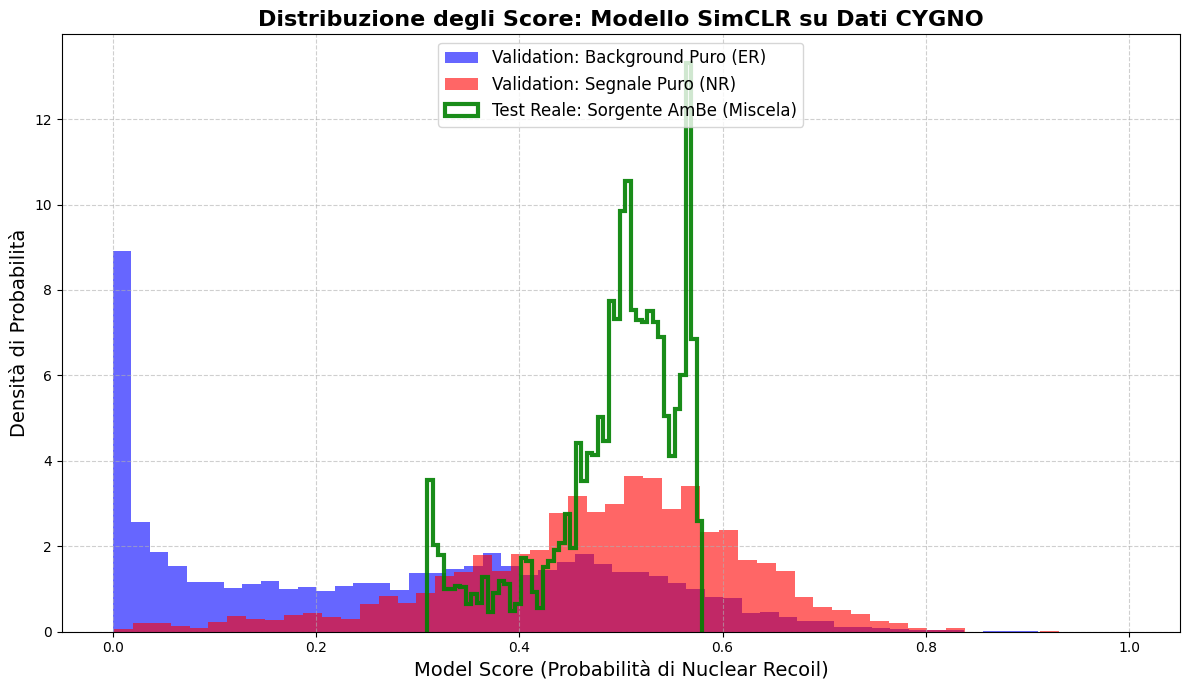


Statistiche Dataset AmBe:
- Tracce totali analizzate: 14724
- Tracce classificate come probabili Nuclear Recoils (Score > 0.8): 0
- Frazione stimata di segnale (Alpha): 0.00%


In [11]:
import matplotlib.pyplot as plt
import numpy as np

print("=== Avvio Fase 3: Inferenza e Valutazione delle Distribuzioni ===")

# 1. Calcoliamo le predizioni (score da 0 a 1) per il Validation Set e per l'AmBe
print("Calcolo delle predizioni in corso...")
# Se hai appena trainato il modello, puoi usare direttamente linear_eval_model
# Altrimenti scommenta la riga sotto per ricaricarlo dal disco:
# linear_eval_model = keras.models.load_model("saved_models/CYGNO_Linear_Classifier_Final.keras")

X_ambe_test = ambe_images_real


scores_val = linear_eval_model.predict(X_val, batch_size=128)
scores_ambe = linear_eval_model.predict(X_ambe_test, batch_size=128)

# 2. Separiamo il validation set usando le label reali per vedere come si comporta il modello
# y_val == 0 sono gli Electronic Recoils (Background)
# y_val == 1 sono i Nuclear Recoils (Signal)
scores_val_bg = scores_val[y_val == 0]
scores_val_sig = scores_val[y_val == 1]

# 3. Creazione del Plot a Istogramma con Densità di Probabilità
plt.figure(figsize=(12, 7))

# density=True fa in modo che l'area totale dell'istogramma sia 1 (Densità di probabilità)
# alpha=0.5 rende i colori trasparenti per vedere le sovrapposizioni

# Plot Background (ER) - Ci aspettiamo che sia tutto schiacciato verso lo 0
plt.hist(scores_val_bg, bins=50, density=True, alpha=0.6, color='blue', 
         label='Validation: Background Puro (ER)')

# Plot Segnale (NR) - Ci aspettiamo che sia tutto schiacciato verso l'1
plt.hist(scores_val_sig, bins=50, density=True, alpha=0.6, color='red', 
         label='Validation: Segnale Puro (NR)')

# Plot AmBe (Miscela Reale) - Usiamo histtype='step' per fare solo il contorno e non pasticciare i colori
plt.hist(scores_ambe, bins=50, density=True, alpha=0.9, color='green', 
         histtype='step', linewidth=3, label='Test Reale: Sorgente AmBe (Miscela)')

# Dettagli estetici del grafico
plt.xlabel('Model Score (Probabilità di Nuclear Recoil)', fontsize=14)
plt.ylabel('Densità di Probabilità', fontsize=14)
plt.title('Distribuzione degli Score: Modello SimCLR su Dati CYGNO', fontsize=16, fontweight='bold')
plt.xlim(-0.05, 1.05) # Fissiamo l'asse X tra 0 e 1 (con un minimo di margine)
plt.legend(fontsize=12, loc='upper center')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. Statistiche veloci sull'AmBe
soglia_taglio = 0.8
nr_candidates = np.sum(scores_ambe > soglia_taglio)
print(f"\nStatistiche Dataset AmBe:")
print(f"- Tracce totali analizzate: {len(scores_ambe)}")
print(f"- Tracce classificate come probabili Nuclear Recoils (Score > {soglia_taglio}): {nr_candidates}")
print(f"- Frazione stimata di segnale (Alpha): {(nr_candidates / len(scores_ambe))*100:.2f}%")